 Bu notebook'un amacı, veriyi temizlemeden veya modele sokmadan önce onun karakterini tam olarak anlamaktır.

1. Kütüphaneler ve Ayarlar:
Analiz sırasında görsellerin net olması ve hataların akışı bozmaması için gerekli yapılandırmayı yapıyoruz.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno # Eksik veri görselleştirme uzmanı

# Grafiklerin notebook içinde görünmesi ve estetik ayarları
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Veriyi yükleyelim
df = pd.read_csv("C:\\Users\\sibel\\source\\repos\\AquaPredict\\data\\water_potability.csv")

print("Veri başarıyla yüklendi.")

Veri başarıyla yüklendi.


2. Veri Profilleme (Data Profiling) :
Verinin genel yapısına, sütun türlerine ve istatistiksel sınırlarına bakıyoruz.

In [6]:
# Sütun türleri ve eksik olmayan değer sayıları
print("--- Genel Bilgiler ---")
df.info()

# Sayısal değerlerin dağılım özeti (min, max, %25, %50, %75)
# Buradaki farklara bakarak aykırı değer (outlier) olup olmadığını sezeriz.
print("\n--- İstatistiksel Özet ---")
display(df.describe().T)

--- Genel Bilgiler ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB

--- İstatistiksel Özet ---


,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


3. Eksik Veri (Missing Value) Derin Analizi: Eksik verileri görselleştirerek verinin hangi bölgelerinde boşluk olduğunu göreceğiz.

                 Toplam Eksik     % Oran
ph                        491  14.987790
Sulfate                   781  23.840049
Trihalomethanes           162   4.945055


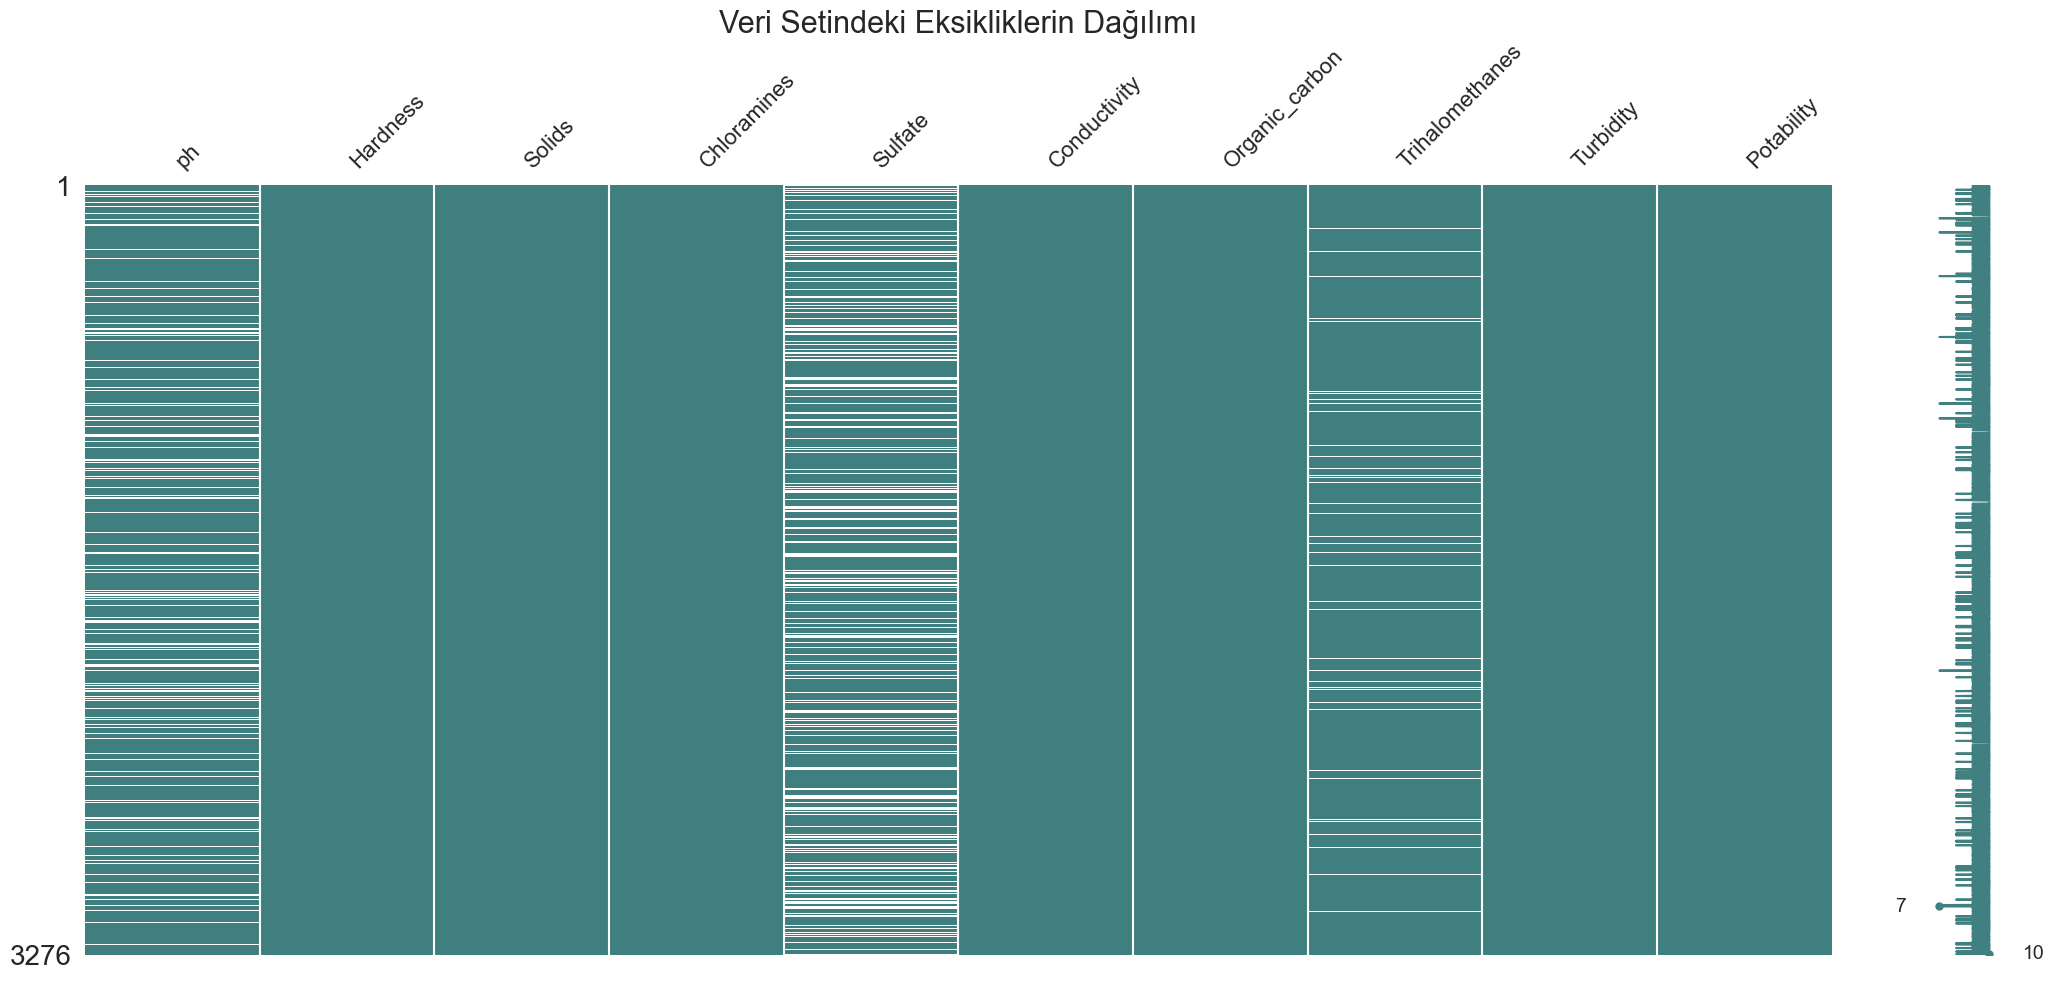

In [7]:
# Eksik verilerin yüzdesel dağılımı
missing_values = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
missing_table = pd.concat([missing_values, missing_percent], axis=1, keys=['Toplam Eksik', '% Oran'])
print(missing_table[missing_table['Toplam Eksik'] > 0])

# Eksik verilerin matris grafiği
# Beyaz çizgiler eksik olan verileri temsil eder.
msno.matrix(df, color=(0.25, 0.5, 0.5))
plt.title("Veri Setindeki Eksikliklerin Dağılımı", fontsize=22)
plt.show()

4. Hedef Değişken (Potability) Dengesi : 
Modelimizin taraflı olup olmayacağını anlamak için "İçilebilir" ve "İçilemez" sınıflarının oranına bakıyoruz.

C:\Users\sibel\AppData\Local\Temp\ipykernel_92476\3939557320.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Potability', palette='viridis')


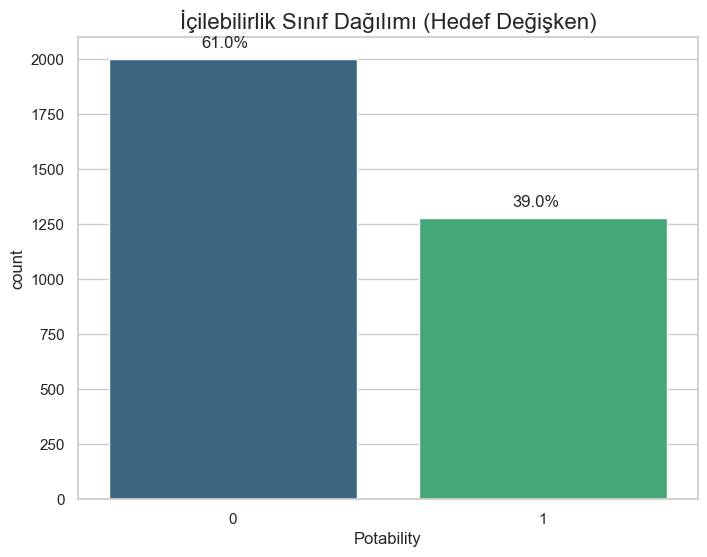

In [8]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Potability', palette='viridis')
plt.title("İçilebilirlik Sınıf Dağılımı (Hedef Değişken)", fontsize=16)

# Grafik üzerine yüzdeleri ekleyelim
for p in ax.patches:
    ax.annotate(f'{100 * p.get_height() / len(df):.1f}%', (p.get_x() + 0.3, p.get_height() + 50))
plt.show()

#Eğer sınıflar arasında büyük bir dengesizlik varsa (inbalanced data), ileride model eğitiminde özel teknikler kullanmamız gerekecektir.

5. Değişkenlerin Dağılımı ve Çarpıklık (Skewness) : 
Her bir parametrenin (pH, Sertlik vb.) nasıl bir dağılım sergilediğini inceliyoruz.

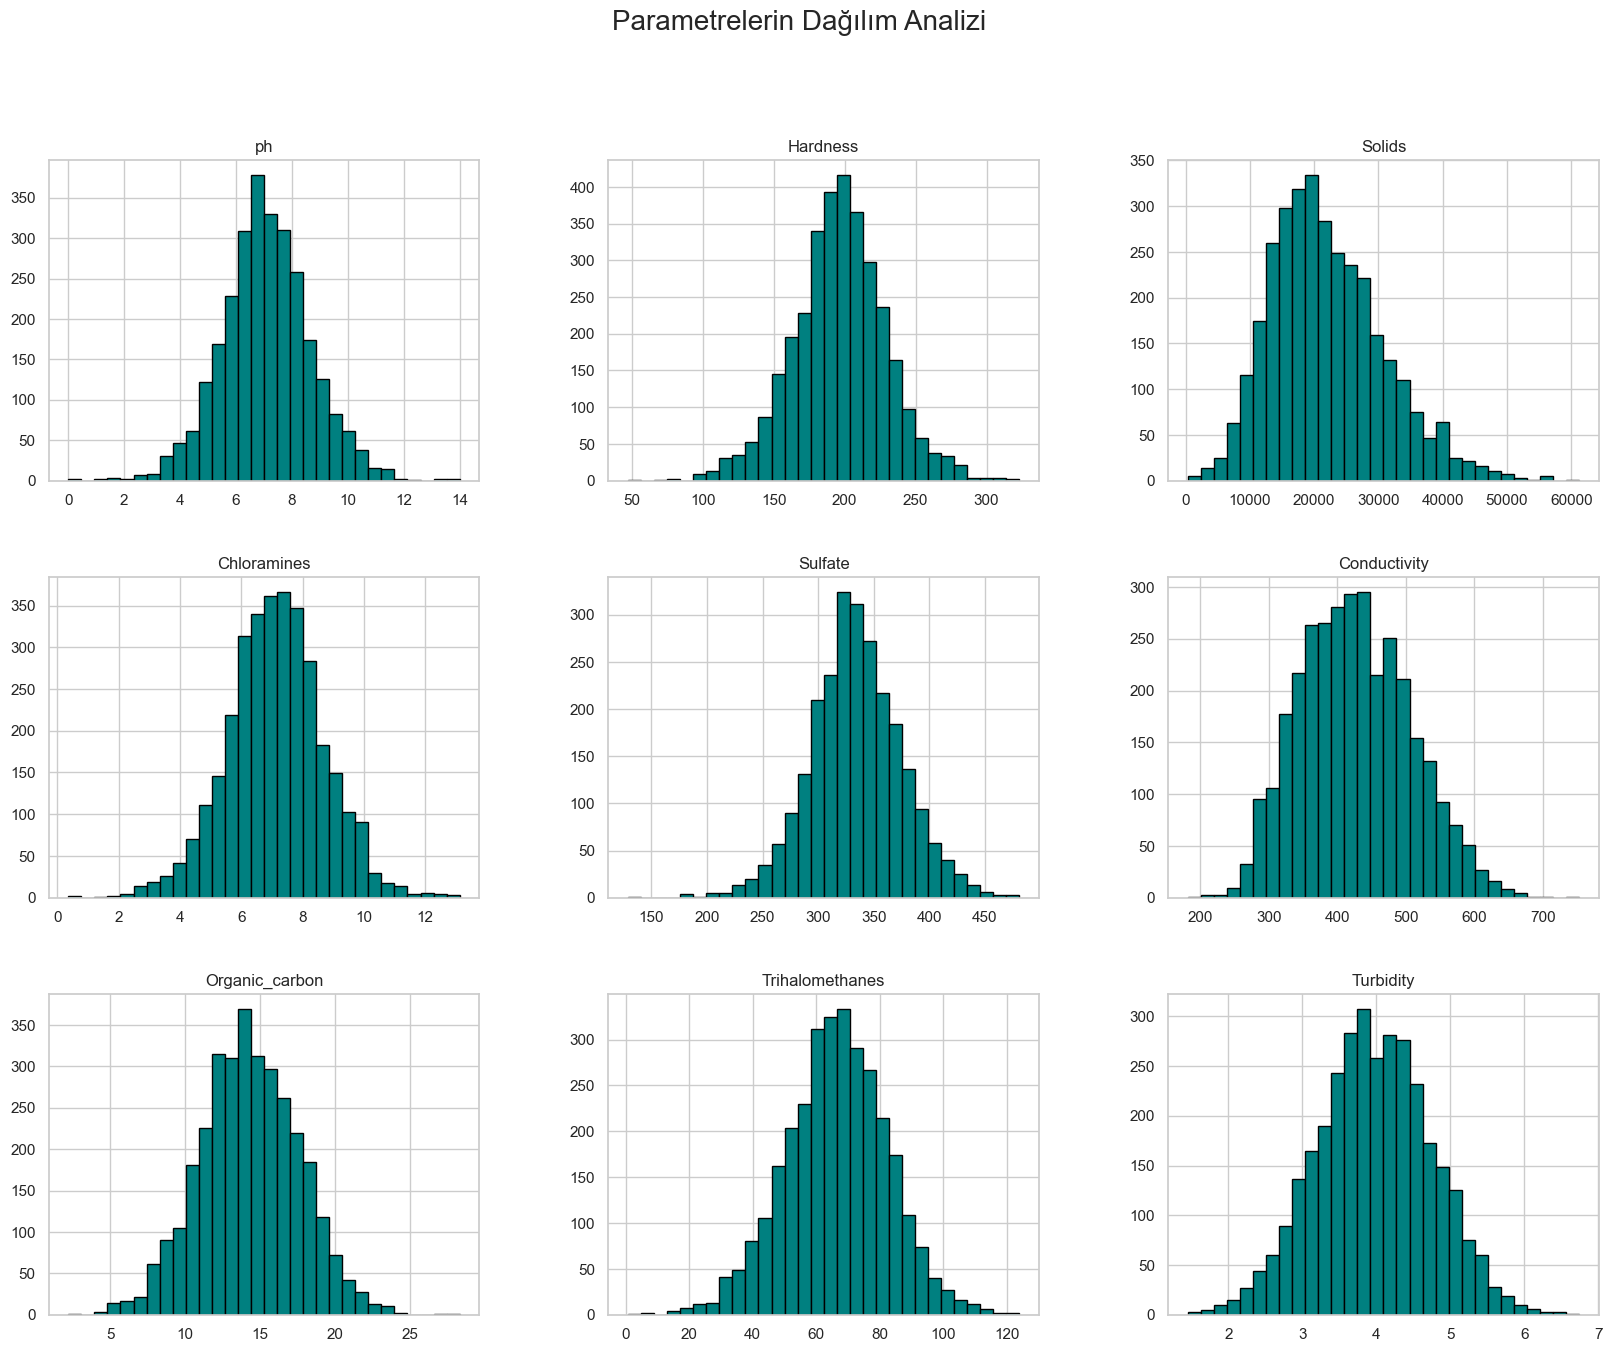

In [13]:
# Tüm sayısal değişkenlerin histogramları
df.drop('Potability', axis=1).hist(bins=30, figsize=(20, 15), color='teal', edgecolor='black')
plt.suptitle("Parametrelerin Dağılım Analizi", fontsize=20)
plt.show()

6. Potability bazlı Özellik Analizi (KDE Plots) : 
Bir parametrenin içilebilirliği nasıl etkilediğini anlamak için "0" ve "1" sınıflarını üst üste bindirerek inceliyoruz.

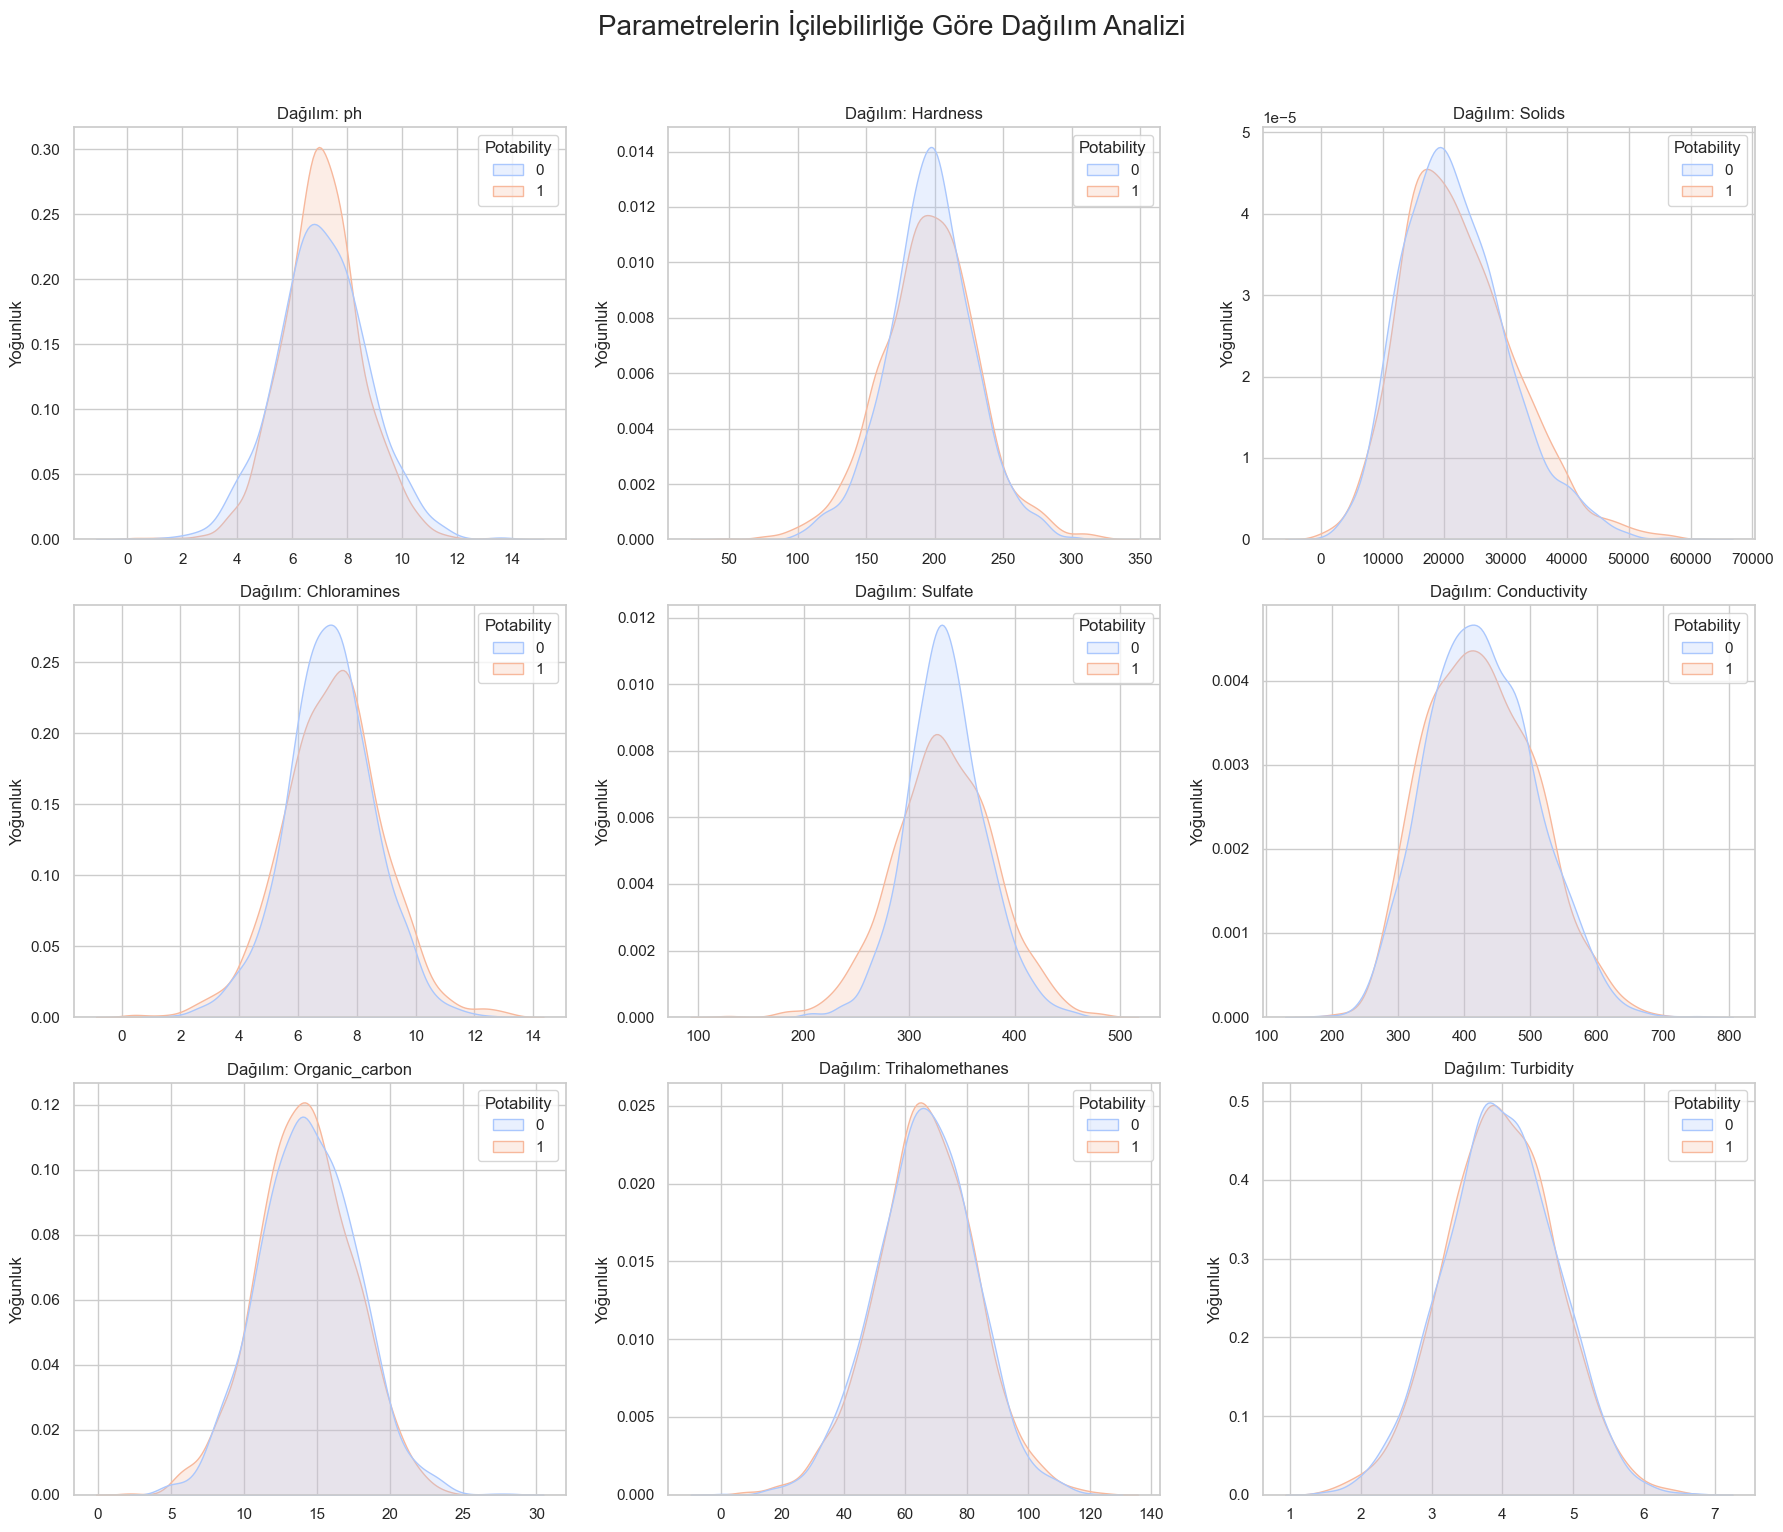

In [12]:
# 'Potability' dışındaki özellik sütunlarını alalım
features = [col for col in df.columns if col != 'Potability']

# 3 satır, 3 sütunluk bir grafik alanı oluşturalım
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
fig.suptitle('Parametrelerin İçilebilirliğe Göre Dağılım Analizi', fontsize=20, y=1.02)

# Eksenleri düz bir listeye çevirelim ki döngüyle kolayca erişelim
axes = axes.flatten()

for i, col in enumerate(features):
    # Her bir alt grafik (axes[i]) için KDE plot çiziyoruz
    sns.kdeplot(data=df, x=col, hue='Potability', fill=True, 
                common_norm=False, palette='coolwarm', ax=axes[i])
    
    axes[i].set_title(f'Dağılım: {col}', fontsize=12)
    axes[i].set_xlabel('') # Eksen kalabalığını önlemek için
    axes[i].set_ylabel('Yoğunluk')

# Boş kalan alan varsa (bizde tam 9 tane var ama yine de düzenleyelim)
plt.tight_layout()
plt.show()

7. Korelasyon Isı Haritası (Correlation Heatmap) : 
Hangi değişkenlerin birbiriyle veya hedef değişkenle güçlü bir ilişkisi var

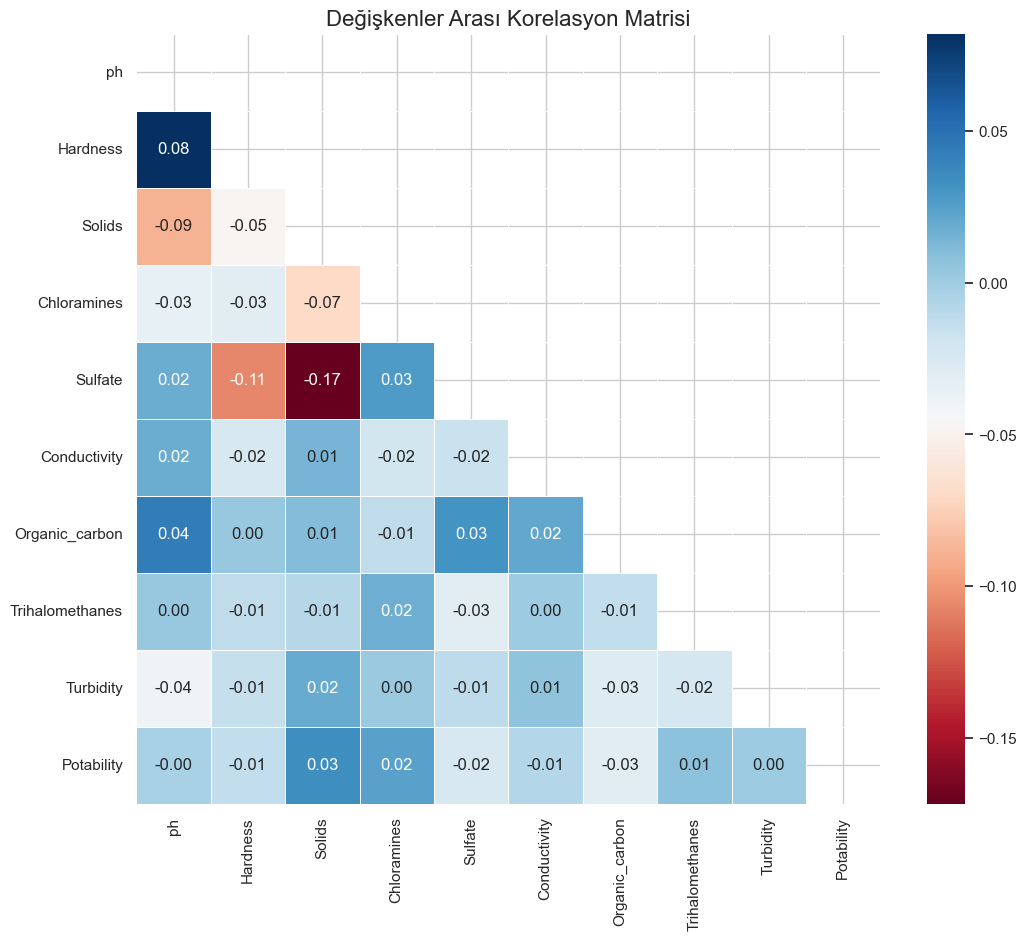

In [16]:
plt.figure(figsize=(12, 10))

# Matrisin üst kısmını (tekrar eden tarafı) kapatmak için maske oluşturalım
mask = np.triu(np.ones_like(df.corr(), dtype=bool))

# Isı haritasını çizelim
sns.heatmap(df.corr(), 
            annot=True,      # Kutucukların içine sayıları yaz
            mask=mask,       # Tekrar eden üst kısmı gizle
            cmap='RdBu',     # Kırmızı (pozitif) - Mavi (negatif) paleti
            fmt='.2f',       # Virgülden sonra 2 basamak göster
            linewidths=0.5)  # Kutucuklar arasına ince çizgi çek

plt.title("Değişkenler Arası Korelasyon Matrisi", fontsize=16)
plt.show()